# Comparing LFC of genes
We create heatmaps for the binned aligned pseudotimes made with cellalign. With those we can see if gene expressions are comparable over time in cells and nuclei

In [ ]:
%run ../Script/analysisLibraries

In [ ]:
%run ../Script/pythonScripts.py

In [ ]:
%matplotlib inline

In [ ]:
%load_ext rpy2.ipython

In [ ]:
adata = sc.read('./write/adata.rf_correction.h5ad')

In [ ]:
import re
geneMask = [ re.match("^MT-|^RPS|^RPL|^MRPS|^MRPL|^CCN|^HLA-|^H2-|^HIST|MTR",i)!=None for i in adata.var_names]

In [ ]:
adata.var_names[geneMask]

Index(['CCNA1', 'CCNB3', 'CCND3', 'HIST1H1A', 'HIST1H1C', 'HIST1H1D',
       'HIST1H2AA', 'HIST1H2BA', 'MRPS27'],
      dtype='object')

In [ ]:
adata = adata[:, np.invert(geneMask)].copy()

In [ ]:
NUCLEI = adata[adata.obs['batch']=='Nuclei'].copy()
CELLS = adata[adata.obs['batch']=='Cells'].copy()

## Uniforming clustering with nuclei as a reference for cells

## Subsampling

Getting as many nuclei as cells

In [ ]:
CELLS

AnnData object with n_obs × n_vars = 2676 × 4991
    obs: 'spl_prop', 'uns_prop', 'perc_rp', 'perc_mito', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'perc_PRM1', 'perc_PRM2', 'perc_LOC104001214', 'perc_KEF41-p07', 'perc_KEF41-p04', 'perc_MTRNR2L14', 'genes_threshold_filter', 'all_filters', 'correction_quantity', 'leiden', 'doublet_score', 'bw_adaptive from LE with bw_adaptive_leiden', 'bw_adaptive from DM with bw_adaptive_leiden', 'topo_leiden_LE', 'topo_leiden_DM', 'SpermatogoniaA_score', 'SpermatogoniaB_score', 'Round.Spt_score', 'Elong.Spt_score', 'Sertoli_score', 'Macroph_score', 'Endothelial_score', 'Myoid_score', 'Smooth_Muscle_score', 'Leptotene_score', 'Zygotene_score', 'Pachytene_score', 'Diplotene_score', 'clusters_single', 'perc_TNP1', 'perc_HSP90AA1', 'batch', 'clusters_compact', 'topo_leiden_LE_merge', 'topo_l

In [ ]:
CELLS.X = CELLS.layers['ml_corrected'].copy()
NUCLEI.X = NUCLEI.layers['ml_corrected'].copy()

In [ ]:
sc.pp.calculate_qc_metrics(CELLS, inplace=True)

In [ ]:
sc.pp.calculate_qc_metrics(NUCLEI, inplace=True)

In [ ]:
del NUCLEI.uns['log1p'], CELLS.uns['log1p']

In [ ]:
sc.pp.normalize_total(NUCLEI)
sc.pp.normalize_total(CELLS)
sc.pp.highly_variable_genes(NUCLEI, n_top_genes=10000)
sc.pp.highly_variable_genes(CELLS, n_top_genes=10000)
sc.pp.log1p(NUCLEI)
sc.pp.log1p(CELLS)

In [ ]:
sc.pp.subsample(NUCLEI, n_obs=CELLS.shape[0], random_state=123)

subsampling counts in each cell

In [ ]:
NUCLEI_S = NUCLEI.copy() #sc.pp.downsample_counts(NUCLEI, counts_per_cell=int(np.mean(CELLS.obs['total_counts'])), copy=True, random_state=123)
CELLS_S = sc.pp.downsample_counts(CELLS, counts_per_cell=int(np.mean(NUCLEI.obs['total_counts'])), copy=True, random_state=123)

## Comparison on whole dataset

selecting only variable genes

In [ ]:
NUCLEI_S = NUCLEI_S[:, NUCLEI.var['highly_variable']|CELLS.var['highly_variable']].copy()

/home/samuele/testis_singlecell/Workspaces/samuele/Environments/Carl_2/lib/python3.11/site-packages/anndata/_core/anndata.py:1105: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if not is_categorical_dtype(df_full[k]):


In [ ]:
CELLS_S = CELLS_S[:, NUCLEI.var['highly_variable']|CELLS.var['highly_variable']].copy()

In [ ]:
Sdata = ad.AnnData.concatenate(NUCLEI_S, CELLS_S, batch_key='Dataset', batch_categories=['Nuclei', 'Cells'])

/home/samuele/testis_singlecell/Workspaces/samuele/Environments/Carl_2/lib/python3.11/site-packages/anndata/_core/merge.py:217: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(dtype):
/home/samuele/testis_singlecell/Workspaces/samuele/Environments/Carl_2/lib/python3.11/site-packages/anndata/_core/merge.py:217: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(dtype):


Change the names of some transcripts to the related genes, so it is easier to understand

In [ ]:
#names = pd.Series(Sdata.var_names, index=Sdata.var_names)
#names[['KEF41-p01','KEF41-p02','KEF41-p03','KEF41-p04','KEF41-p05','KEF41-p06',
#       'KEF41-p07','KEF41-p08','KEF41-p09','KEF41-p10','KEF41-p11','KEF41-p12',
#       'KEF41-p13']] = ['CYTB','ND6','ND5','ND4','ND4L','ND3','COX3','ATP6','ATP8','COX2','COX1','ND2','ND1']

In [ ]:
#Sdata.var_names = np.array(names)

In [ ]:
Sdata.obs

,spl_prop,uns_prop,perc_rp,perc_mito,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,...,perc_TNP1,perc_HSP90AA1,batch,clusters_compact,topo_leiden_LE_merge,topo_leiden_DM_merge,Eigenvector_5,dpt_palantir,dpt_palantir_cellalign,Dataset
GTACAGTTCCACTAGA-Nuclei-Nuclei,0.408483,0.591517,0.017813,0.009780,259,5.560682,278.216522,5.631988,29.752545,50.314667,...,NaN,NaN,Nuclei,Spermatocites,5,4,0.017678,0.394379,0.387782,Nuclei
TTGAGTGCATATGGCT-Nuclei-Nuclei,0.380919,0.619081,0.014091,0.006191,515,6.246107,462.650841,6.139132,21.619796,34.880123,...,NaN,NaN,Nuclei,Spermatocites,3,9,-0.015120,0.201830,0.202029,Nuclei
ATCAGGTGTGGCCCAT-Nuclei-Nuclei,0.453751,0.546249,0.011589,0.012619,439,6.086775,431.579375,6.069766,22.260279,37.218034,...,NaN,NaN,Nuclei,Round.Spt,9,7,-0.003947,0.633780,0.632698,Nuclei
CTTAGGACAATCTCGA-Nuclei-Nuclei,0.270235,0.729765,0.010304,0.014426,587,6.376727,466.796333,6.148033,19.077504,31.988392,...,NaN,NaN,Nuclei,SpermatogoniaB,10,11,-0.000224,0.098182,0.101969,Nuclei
TGCGGCACAATCAAGA-Nuclei-Nuclei,0.442765,0.557235,0.015827,0.009690,497,6.210600,542.020331,6.297147,18.375089,31.092842,...,NaN,NaN,Nuclei,Round.Spt,2,5,-0.006347,0.733509,0.734690,Nuclei
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTGTTGCAGCGGTCT-Cells-Cells,0.408861,0.591139,0.008378,0.010828,4884,8.493925,583.464921,6.370697,16.870528,28.362581,...,0.000000,0.000143,Cells,Round.Spt,2,5,-0.015542,0.749503,0.755097,Cells
TTTGTTGGTACAGTCT-Cells-Cells,0.549630,0.450370,0.009534,0.008331,4886,8.494334,584.649136,6.372721,13.790901,23.176386,...,0.008751,0.000000,Cells,Round.Spt,0,0,0.001205,0.857129,0.857129,Cells
TTTGTTGGTCTACGTA-Cells-Cells,0.533394,0.466606,0.017171,0.013123,4635,8.441607,325.222511,5.787580,22.865528,35.108664,...,0.000000,0.001729,Cells,Spermatocites,5,4,-0.008319,0.556596,0.551342,Cells
TTTGTTGTCCATTTAC-Cells-Cells,0.497133,0.502867,0.011296,0.021899,4686,8.452548,264.895424,5.583103,29.553584,48.665470,...,0.000000,0.004952,Cells,Spermatocites,6,16,0.007709,0.290586,0.285761,Cells


/home/samuele/testis_singlecell/Workspaces/samuele/Environments/Carl_2/lib/python3.11/site-packages/anndata/_core/anndata.py:1105: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if not is_categorical_dtype(df_full[k]):
/home/samuele/testis_singlecell/Workspaces/samuele/Environments/Carl_2/lib/python3.11/site-packages/anndata/_core/anndata.py:1105: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if not is_categorical_dtype(df_full[k]):
/home/samuele/testis_singlecell/Workspaces/samuele/Environments/Carl_2/lib/python3.11/site-packages/anndata/_core/anndata.py:1105: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if not is_categorical_dtype(df_full[k]):
/home/samuele/testis_singlecell/Works

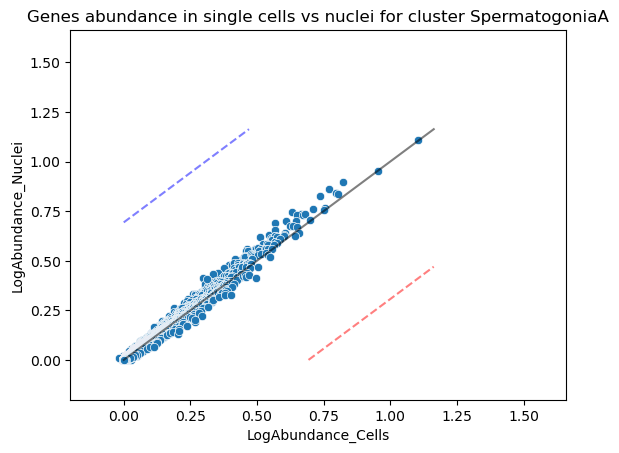

/home/samuele/testis_singlecell/Workspaces/samuele/Environments/Carl_2/lib/python3.11/site-packages/anndata/_core/anndata.py:1105: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if not is_categorical_dtype(df_full[k]):
/home/samuele/testis_singlecell/Workspaces/samuele/Environments/Carl_2/lib/python3.11/site-packages/anndata/_core/anndata.py:1105: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if not is_categorical_dtype(df_full[k]):
/home/samuele/testis_singlecell/Workspaces/samuele/Environments/Carl_2/lib/python3.11/site-packages/anndata/_core/anndata.py:1105: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if not is_categorical_dtype(df_full[k]):
/home/samuele/testis_singlecell/Works

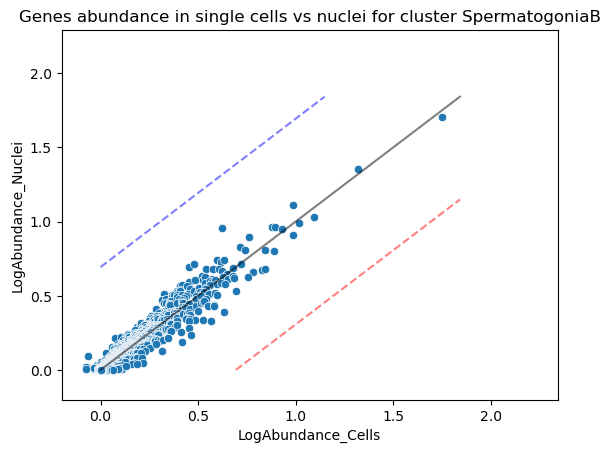

/home/samuele/testis_singlecell/Workspaces/samuele/Environments/Carl_2/lib/python3.11/site-packages/anndata/_core/anndata.py:1105: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if not is_categorical_dtype(df_full[k]):
/home/samuele/testis_singlecell/Workspaces/samuele/Environments/Carl_2/lib/python3.11/site-packages/anndata/_core/anndata.py:1105: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if not is_categorical_dtype(df_full[k]):
/home/samuele/testis_singlecell/Workspaces/samuele/Environments/Carl_2/lib/python3.11/site-packages/anndata/_core/anndata.py:1105: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if not is_categorical_dtype(df_full[k]):
/home/samuele/testis_singlecell/Works

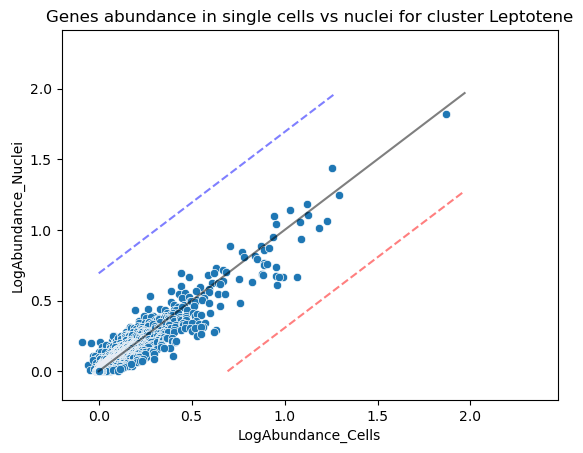

/home/samuele/testis_singlecell/Workspaces/samuele/Environments/Carl_2/lib/python3.11/site-packages/anndata/_core/anndata.py:1105: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if not is_categorical_dtype(df_full[k]):
/home/samuele/testis_singlecell/Workspaces/samuele/Environments/Carl_2/lib/python3.11/site-packages/anndata/_core/anndata.py:1105: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if not is_categorical_dtype(df_full[k]):
/home/samuele/testis_singlecell/Workspaces/samuele/Environments/Carl_2/lib/python3.11/site-packages/anndata/_core/anndata.py:1105: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if not is_categorical_dtype(df_full[k]):
/home/samuele/testis_singlecell/Works

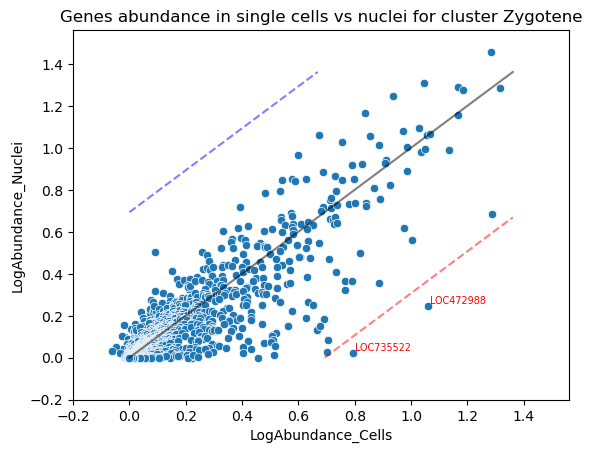

Cells-abundant genes:


,Gene,LogMeanNuclei,LogMeanCells,FC
4834,LOC735522,0.020759,0.792920,2.164439
4836,LOC472988,0.244762,1.061414,2.262910


/home/samuele/testis_singlecell/Workspaces/samuele/Environments/Carl_2/lib/python3.11/site-packages/anndata/_core/anndata.py:1105: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if not is_categorical_dtype(df_full[k]):
/home/samuele/testis_singlecell/Workspaces/samuele/Environments/Carl_2/lib/python3.11/site-packages/anndata/_core/anndata.py:1105: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if not is_categorical_dtype(df_full[k]):
/home/samuele/testis_singlecell/Workspaces/samuele/Environments/Carl_2/lib/python3.11/site-packages/anndata/_core/anndata.py:1105: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if not is_categorical_dtype(df_full[k]):
/home/samuele/testis_singlecell/Works

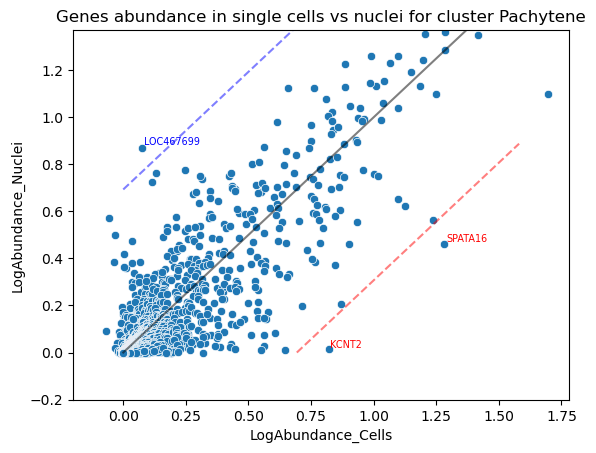

Nuclei-abundant genes:


,Gene,LogMeanNuclei,LogMeanCells,FC
38,LOC467699,0.870982,0.074290,2.218191


Cells-abundant genes:


,Gene,LogMeanNuclei,LogMeanCells,FC
4919,KCNT2,0.014336,0.822432,2.243632
4939,SPATA16,0.459338,1.280758,2.273725


/home/samuele/testis_singlecell/Workspaces/samuele/Environments/Carl_2/lib/python3.11/site-packages/anndata/_core/anndata.py:1105: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if not is_categorical_dtype(df_full[k]):
/home/samuele/testis_singlecell/Workspaces/samuele/Environments/Carl_2/lib/python3.11/site-packages/anndata/_core/anndata.py:1105: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if not is_categorical_dtype(df_full[k]):
/home/samuele/testis_singlecell/Workspaces/samuele/Environments/Carl_2/lib/python3.11/site-packages/anndata/_core/anndata.py:1105: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if not is_categorical_dtype(df_full[k]):
/home/samuele/testis_singlecell/Works

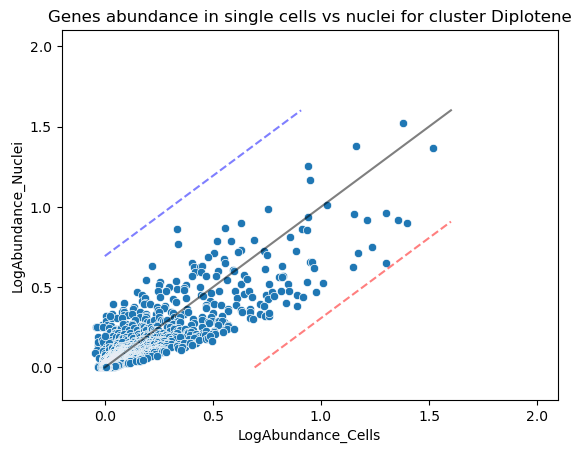

/home/samuele/testis_singlecell/Workspaces/samuele/Environments/Carl_2/lib/python3.11/site-packages/anndata/_core/anndata.py:1105: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if not is_categorical_dtype(df_full[k]):
/home/samuele/testis_singlecell/Workspaces/samuele/Environments/Carl_2/lib/python3.11/site-packages/anndata/_core/anndata.py:1105: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if not is_categorical_dtype(df_full[k]):
/home/samuele/testis_singlecell/Workspaces/samuele/Environments/Carl_2/lib/python3.11/site-packages/anndata/_core/anndata.py:1105: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if not is_categorical_dtype(df_full[k]):
/home/samuele/testis_singlecell/Works

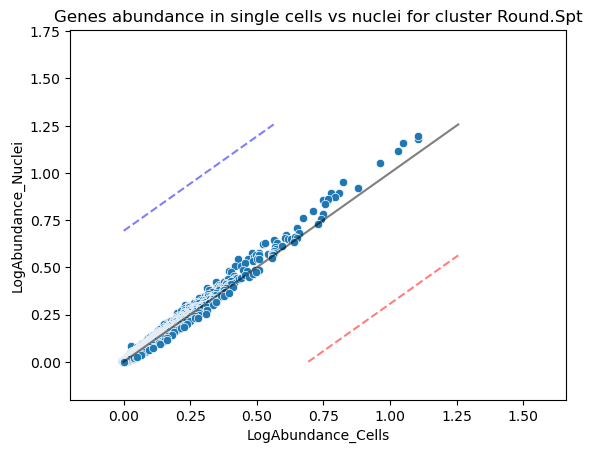

/home/samuele/testis_singlecell/Workspaces/samuele/Environments/Carl_2/lib/python3.11/site-packages/anndata/_core/anndata.py:1105: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if not is_categorical_dtype(df_full[k]):
/home/samuele/testis_singlecell/Workspaces/samuele/Environments/Carl_2/lib/python3.11/site-packages/anndata/_core/anndata.py:1105: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if not is_categorical_dtype(df_full[k]):
/home/samuele/testis_singlecell/Workspaces/samuele/Environments/Carl_2/lib/python3.11/site-packages/anndata/_core/anndata.py:1105: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if not is_categorical_dtype(df_full[k]):
/home/samuele/testis_singlecell/Works

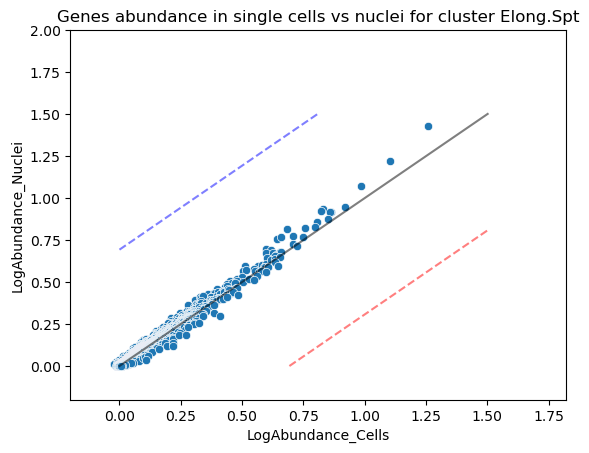

In [ ]:
from adjustText import adjust_text

for CLUSTER in ['SpermatogoniaA', 'SpermatogoniaB', 'Leptotene',  'Zygotene' ,  
    'Pachytene', 'Diplotene', 'Round.Spt', 'Elong.Spt']:
    
    from IPython.display import display
    
    Sdata_2 = Sdata[Sdata.obs['clusters_single']==CLUSTER].copy()
    sc.tl.rank_genes_groups(Sdata_2, groupby='Dataset',  reference='Cells')
    result = Sdata_2.uns['rank_genes_groups']
    Sdata.uns[f'rank_genes_groups_{CLUSTER}'] = Sdata_2.uns['rank_genes_groups'].copy()
    groups = result['names'].dtype.names
    X = pd.DataFrame(
     {group + '_' + key[:1].upper(): result[key][group]
     for group in groups for key in ['names', 'pvals_adj','logfoldchanges']})

    Ndata = Sdata_2[ Sdata_2.obs['Dataset']=='Nuclei' ].copy()
    nuclei_ab = np.ravel(np.mean(Ndata[:, X['Nuclei_N']].X, 0 ))

    Cdata = Sdata_2[ Sdata_2.obs['Dataset']=='Cells' ].copy()
    cells_ab = np.ravel( np.mean(Cdata[:, X['Nuclei_N']].X, 0) )
    
    X['LogAbundance_Cells'] = cells_ab
    X['LogAbundance_Nuclei'] = nuclei_ab
    X['Abundance_Cells'] = np.exp(cells_ab)
    X['Abundance_Nuclei'] = np.exp(nuclei_ab)
        
    fig, ax = plt.subplots(1,1)
    f = sns.scatterplot(data=X,
          x='LogAbundance_Cells',
          y='LogAbundance_Nuclei',
          ax=ax)

    Xsub_N = X.query('LogAbundance_Nuclei-LogAbundance_Cells>0.69 & Nuclei_P<.0001')
    Xsub_C = X.query('LogAbundance_Cells-LogAbundance_Nuclei>0.69 & Nuclei_P<.0001')
    
    if( (Xsub_N.shape[0]>0) & (Xsub_C.shape[0]>0) ):
     xmax = np.max( Xsub_C.LogAbundance_Cells )
     ymax = np.max( Xsub_N.LogAbundance_Nuclei )
     max_all = np.max([xmax,ymax])+.3
    elif( (Xsub_N.shape[0]>0) & (Xsub_C.shape[0]==0) ):
     ymax = np.max( Xsub_N.LogAbundance_Nuclei )
     xmax=ymax
     max_all = np.max([xmax,ymax])+.3
    elif( (Xsub_N.shape[0]==0) & (Xsub_C.shape[0]>0) ):
     xmax = np.max( Xsub_C.LogAbundance_Cells )
     ymax=xmax
     max_all = np.max([xmax,ymax])+.3
    else:
     xmax = ax.get_xlim()[1]
     ymax = ax.get_ylim()[1]
     max_all = np.max([xmax,ymax])    

    ax.set_xlim(-.2, xmax+.5)
    ax.set_ylim(-.2, ymax+.5)
    
    ax.plot([0,max_all],[0,max_all], color='black', alpha=.5)
    ax.plot([np.log(2),max_all],[0,max_all-np.log(2)], linestyle='dashed', color='red', alpha=.5)
    ax.plot([0,max_all-np.log(2)],[np.log(2),max_all], linestyle='dashed', color='blue',alpha=.5)

    texts = []
    
    Xsub = X.query('LogAbundance_Nuclei-LogAbundance_Cells>0.69')
    for IDX in Xsub.index:
     x_coord = Xsub.loc[IDX,'LogAbundance_Cells']
     y_coord = Xsub.loc[IDX,'LogAbundance_Nuclei']
     text = Xsub.loc[IDX,'Nuclei_N']
     texts.append(ax.text(x_coord, y_coord, text, fontsize='x-small', color='blue'))

    Xsub = X.query('LogAbundance_Cells-LogAbundance_Nuclei>0.69')
    for IDX in Xsub.index:
     x_coord = Xsub.loc[IDX,'LogAbundance_Cells']
     y_coord = Xsub.loc[IDX,'LogAbundance_Nuclei']
     text = Xsub.loc[IDX,'Nuclei_N']
     texts.append(ax.text(x_coord, y_coord, text, fontsize='x-small', color='red'))
    
    adjust_text(texts, arrowprops=dict(arrowstyle='-', color='gray', lw=0.5))
    
    title=ax.set_title(f'Genes abundance in single cells vs nuclei for cluster {CLUSTER}')

    plt.savefig(f'./{CLUSTER}_LFC.png', bbox_inches='tight', transparent=True )
    plt.show()

    if((Xsub_N.shape[0]>0)):
     print("Nuclei-abundant genes:")
     Xsub_N = Xsub_N[ ['Nuclei_N', 'LogAbundance_Nuclei', 'LogAbundance_Cells'] ]
     Xsub_N.columns = ['Gene', 'LogMeanNuclei', 'LogMeanCells']
     Xsub_N['FC'] = np.exp(Xsub_N.LogMeanNuclei - Xsub_N.LogMeanCells)
     display( Xsub_N.style )
     Xsub_N.to_csv(f'{CLUSTER}_LFC_Nuclei.csv', index_label=False)
    if((Xsub_C.shape[0]>0)):
     print("Cells-abundant genes:")
     Xsub_C = Xsub_C[ ['Nuclei_N', 'LogAbundance_Nuclei', 'LogAbundance_Cells'] ]
     Xsub_C.columns = ['Gene', 'LogMeanNuclei', 'LogMeanCells']
     Xsub_C['FC'] = np.exp(Xsub_C.LogMeanCells - Xsub_C.LogMeanNuclei)
     display( Xsub_C.style )
     Xsub_C.to_csv(f'{CLUSTER}_LFC_Cells.csv', index_label=False)

In [ ]:
Sdata.write('./write/LFC_comparison_mlcorrected.h5ad')

## GSEA analysis

In [ ]:
Sdata = sc.read('./write/LFC_comparison_mlcorrected.h5ad')

In [ ]:
# Get all cluster names from the rank_genes_groups keys in Sdata.uns
cluster_names = ['SpermatogoniaA', 'SpermatogoniaB', 'Leptotene', 'Zygotene', 
                 'Pachytene', 'Diplotene', 'Round.Spt', 'Elong.Spt']

# Create a list to store dataframes for each cluster
dfs_list = []

for cluster in cluster_names:
    # Get the rank_genes_groups result for this cluster
    result = Sdata.uns[f'rank_genes_groups_{cluster}']
    groups = result['names'].dtype.names
    
    # Create dataframe with all the information
    df = pd.DataFrame({
        group + '_' + key[:1].upper(): result[key][group]
        for group in groups for key in ['names', 'pvals_adj', 'logfoldchanges']
    })
    
    # Add cluster column
    df['Cluster'] = cluster
    
    # Append to list
    dfs_list.append(df)

# Concatenate all dataframes
all_clusters_df = pd.concat(dfs_list, ignore_index=True)

# Display the result
all_clusters_df

,Nuclei_N,Nuclei_P,Nuclei_L,Cluster
0,LOC107966751,1.747951e-81,NaN,SpermatogoniaA
1,LOC107970084,1.747951e-81,NaN,SpermatogoniaA
2,LOC104002639,2.057794e-81,NaN,SpermatogoniaA
3,LOC107970688,7.943477e-81,NaN,SpermatogoniaA
4,LOC101057999,6.106819e-62,NaN,SpermatogoniaA
...,...,...,...,...
39923,LOC107967937,3.689546e-56,-15.366011,Elong.Spt
39924,LRRC2,2.523708e-58,-19.857626,Elong.Spt
39925,C18H18orf63,8.596032e-75,-16.215633,Elong.Spt
39926,LOC107969901,1.165352e-83,-20.199364,Elong.Spt


In [ ]:
all_clusters_df.to_csv('./tables_LFC_comparison_all_clusters_mlcorrected.csv', index=False)

### Now use R for the analysis

In [1]:
library(clusterProfiler)
library(ggplot2)
library(dplyr)
library(org.Pt.eg.db)
library(enrichplot)



clusterProfiler v4.14.0 Learn more at https://yulab-smu.top/contribution-knowledge-mining/

Please cite:

Guangchuang Yu, Li-Gen Wang, Yanyan Han and Qing-Yu He.
clusterProfiler: an R package for comparing biological themes among
gene clusters. OMICS: A Journal of Integrative Biology. 2012,
16(5):284-287


Attaching package: ‘clusterProfiler’


The following object is masked from ‘package:stats’:

    filter



Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Loading required package: AnnotationDbi

Loading required package: stats4

Loading required package: BiocGenerics


Attaching package: ‘BiocGenerics’


The following objects are masked from ‘package:dplyr’:

    combine, intersect, setdiff, union


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects are masked from ‘package:

In [2]:
dgeAll = read.table('./tables_LFC_comparison_all_clusters_mlcorrected.csv', header=TRUE, sep=',')

In [3]:
#scripts for the analysis
source("../Script/analysis.R")
#Create results folder
RES_FOLDER = paste0("GSEA_ORA_LFC_COMPARISON")
dir.create(RES_FOLDER, showWarnings = FALSE, recursive = TRUE)

In [4]:
clusters <- dgeAll$Cluster %>% unique()

In [5]:
allBP <- list()
allMF <- list()
allCC <- list()
objBP <- list()
objMF <- list()
objCC <- list()

for(CLST in clusters){

    dge <- dgeAll %>%
    filter(Cluster == CLST) %>%
    arrange(desc(Nuclei_L))

    #extract entrez IDs 
    xx <- as.list(org.Pt.egALIAS2EG)
    n <- sapply(names(xx), toupper)
    names(xx) = unlist(n)
    new_n <- sapply(dge$Nuclei_N,  function(ID){
                newname <- xx[ID][1]
                if( newname=="NULL" | is.null(newname) ){
                    newname <- ID }
                return(newname)
                    })
    #add entrez ids to the table as a new column
    dge['ENTREZID'] = make.unique(as.character(new_n), sep=".")
    dge_no_NA <- dge[!is.na(dge$Nuclei_L), , drop=FALSE]
    gene_list <- dge$Nuclei_L
    names(gene_list) = dge$ENTREZID
    gene_list <- sort(gene_list, decreasing = TRUE)

    # Now run gseGO
    egoBP <- gseGO(
    geneList     = gene_list,
    OrgDb        = org.Pt.eg.db,
    keyType      = "ENTREZID",
    ont          = "BP",
    minGSSize    = 5, # minimum gene set size
    maxGSSize    = 500, # maximum gene set size. The bigger, the more biologically general the GO terms you obtain
    pvalueCutoff = 0.05, # significance cutoff
    verbose      = FALSE
    )
    egoMF <- gseGO(
    geneList     = gene_list,
    OrgDb        = org.Pt.eg.db,
    keyType      = "ENTREZID",
    ont          = "MF",
    minGSSize    = 5,
    maxGSSize    = 500,
    pvalueCutoff = 0.05,
    verbose      = FALSE
    )
    egoCC <- gseGO(
    geneList     = gene_list,
    OrgDb        = org.Pt.eg.db,
    keyType      = "ENTREZID",
    ont          = "CC",
    minGSSize    = 5,
    maxGSSize    = 500,
    pvalueCutoff = 0.05,
    verbose      = FALSE
    )

objBP[[CLST]] <- egoBP
objMF[[CLST]] <- egoMF
objCC[[CLST]] <- egoCC
allBP[[CLST]] <- egoBP@result
allMF[[CLST]] <- egoMF@result
allCC[[CLST]] <- egoCC@result

}

Warning message in fgseaMultilevel(pathways = pathways, stats = stats, minSize = minSize, :
“For some of the pathways the P-values were likely overestimated. For such pathways log2err is set to NA.”
no term enriched under specific pvalueCutoff...

Warning message in fgseaMultilevel(pathways = pathways, stats = stats, minSize = minSize, :
“There were 2 pathways for which P-values were not calculated properly due to unbalanced (positive and negative) gene-level statistic values. For such pathways pval, padj, NES, log2err are set to NA. You can try to increase the value of the argument nPermSimple (for example set it nPermSimple = 10000)”
Warning message in fgseaMultilevel(pathways = pathways, stats = stats, minSize = minSize, :
“For some of the pathways the P-values were likely overestimated. For such pathways log2err is set to NA.”
no term enriched under specific pvalueCutoff...

Warning message in fgseaMultilevel(pathways = pathways, stats = stats, minSize = minSize, :
“There were 1 pa

In [6]:
allBP

ID,Description,setSize,enrichmentScore,NES,pvalue,p.adjust,qvalue
<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ID,Description,setSize,enrichmentScore,NES,pvalue,p.adjust,qvalue
<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ID,Description,setSize,enrichmentScore,NES,pvalue,p.adjust,qvalue
<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ID,Description,setSize,enrichmentScore,NES,pvalue,p.adjust,qvalue
<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ID,Description,setSize,enrichmentScore,NES,pvalue,p.adjust,qvalue
<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ID,Description,setSize,enrichmentScore,NES,pvalue,p.adjust,qvalue


In [7]:
allMF

ID,Description,setSize,enrichmentScore,NES,pvalue,p.adjust,qvalue
<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ID,Description,setSize,enrichmentScore,NES,pvalue,p.adjust,qvalue
<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ID,Description,setSize,enrichmentScore,NES,pvalue,p.adjust,qvalue
<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ID,Description,setSize,enrichmentScore,NES,pvalue,p.adjust,qvalue
<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ID,Description,setSize,enrichmentScore,NES,pvalue,p.adjust,qvalue
<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ID,Description,setSize,enrichmentScore,NES,pvalue,p.adjust,qvalue


In [8]:
allCC

ID,Description,setSize,enrichmentScore,NES,pvalue,p.adjust,qvalue
<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ID,Description,setSize,enrichmentScore,NES,pvalue,p.adjust,qvalue
<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ID,Description,setSize,enrichmentScore,NES,pvalue,p.adjust,qvalue
<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ID,Description,setSize,enrichmentScore,NES,pvalue,p.adjust,qvalue
<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ID,Description,setSize,enrichmentScore,NES,pvalue,p.adjust,qvalue
<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ID,Description,setSize,enrichmentScore,NES,pvalue,p.adjust,qvalue


pdf 
  2

pdf 
  2

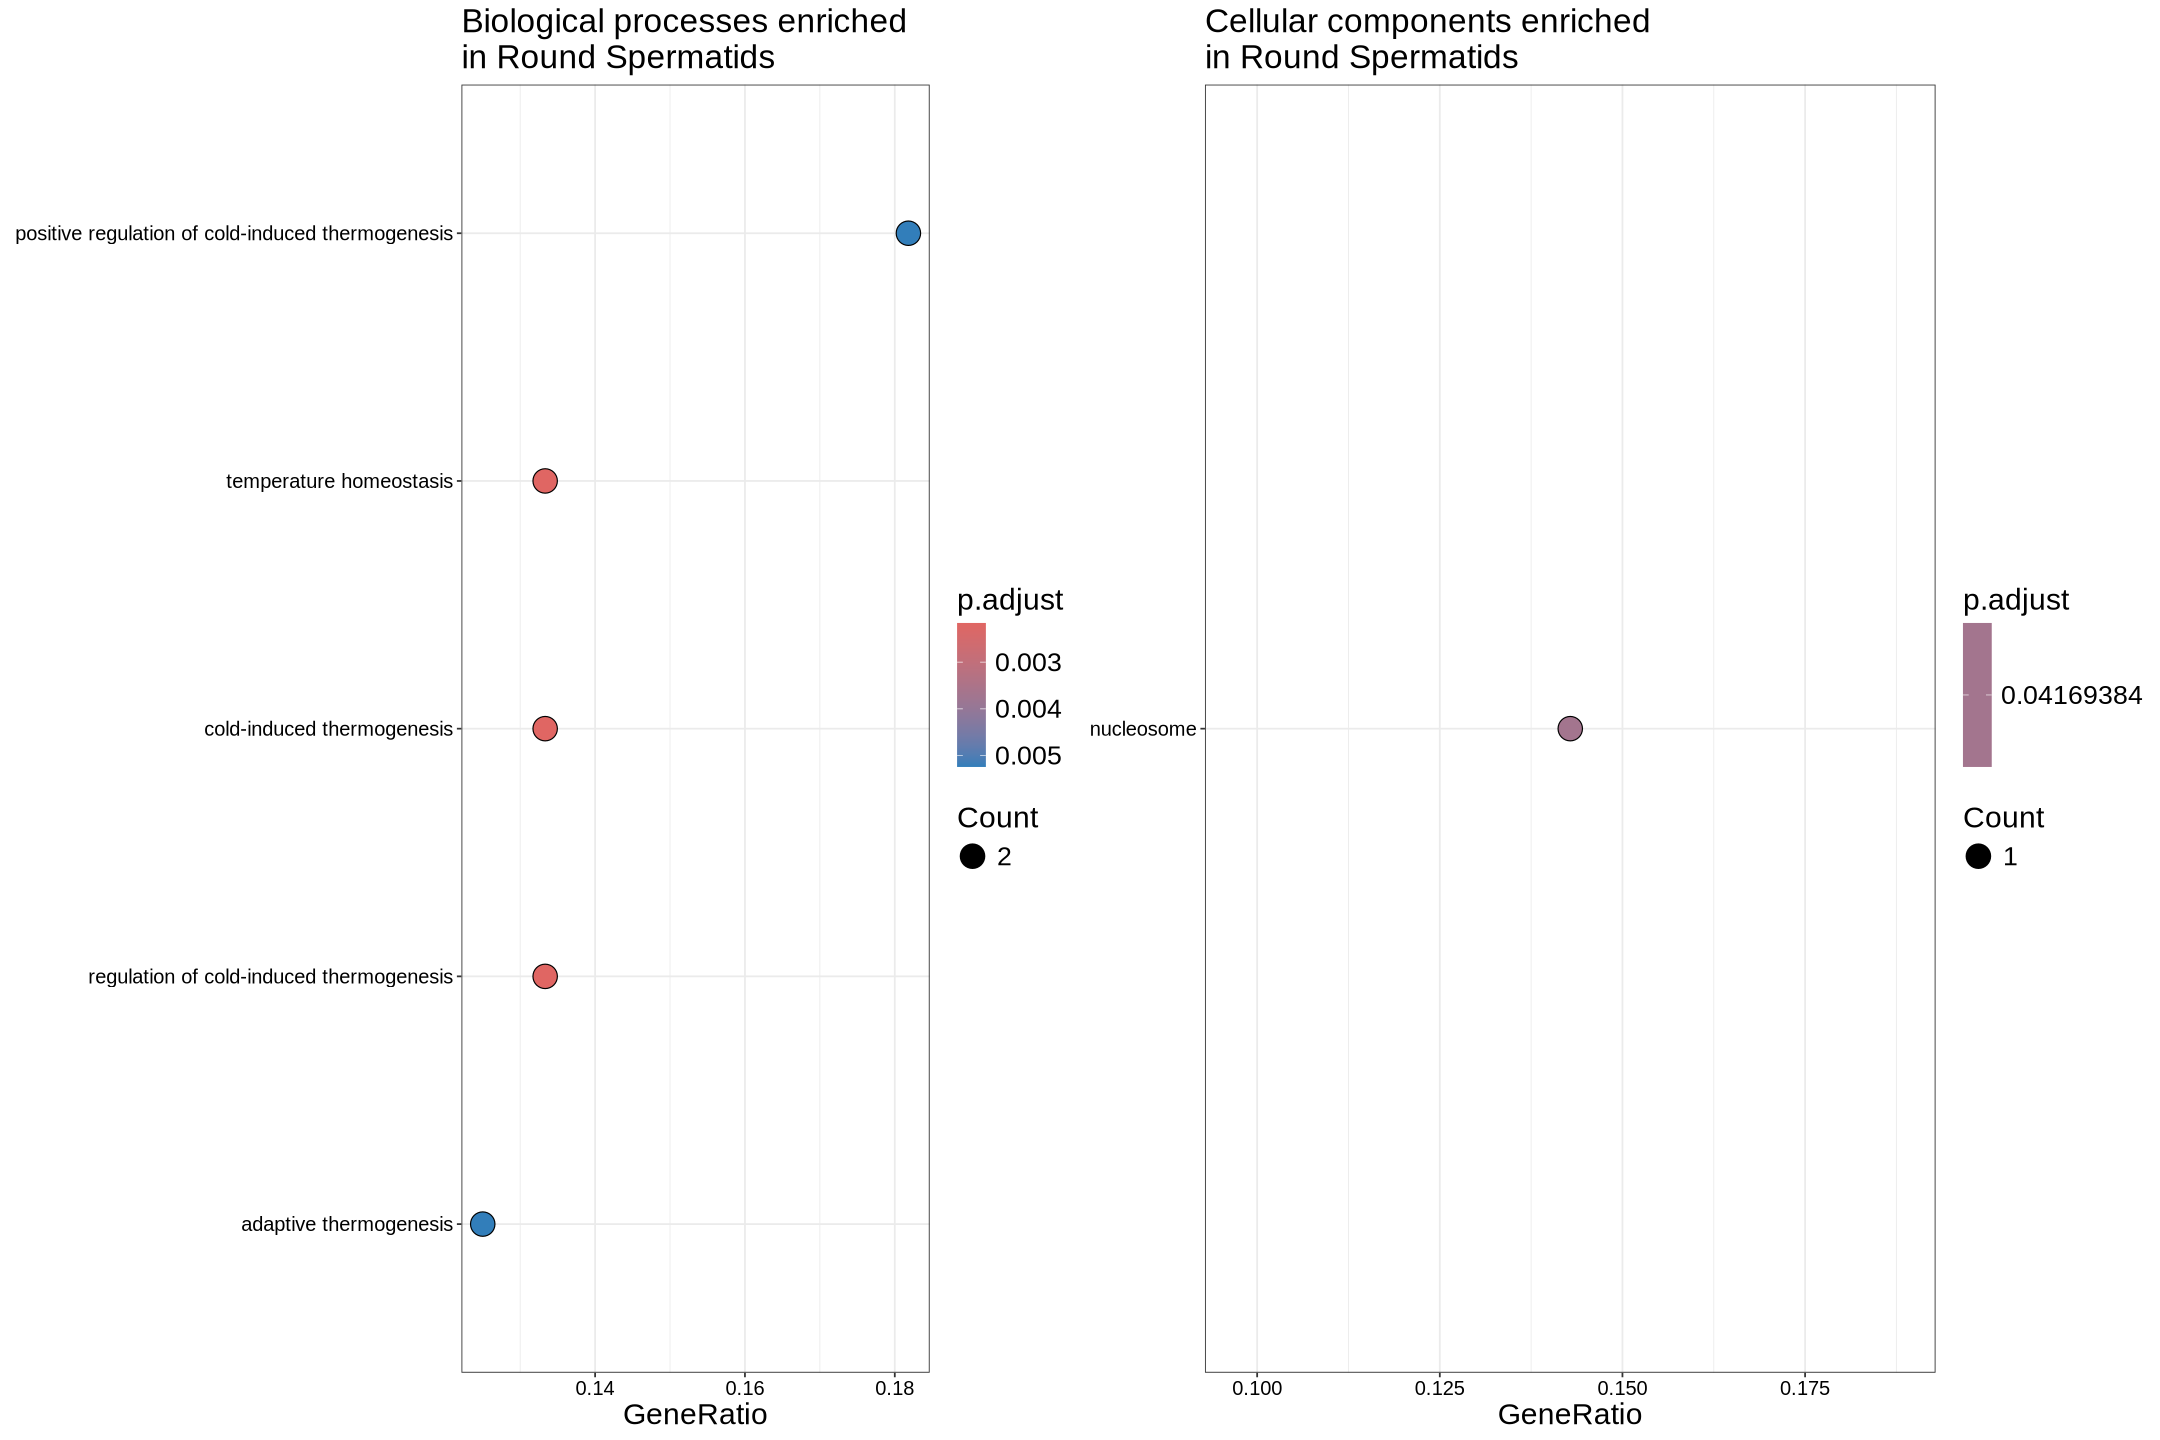

In [10]:
options(repr.plot.width=18, repr.plot.height=12)

plot1 = dotplot(objBP$Round.Spt, showCategory=20, label_format = 50) +
    ggtitle("Biological processes enriched\nin Round Spermatids") +
    theme(
        legend.text = element_text(size = 16),
        legend.title = element_text(size = 18),
        axis.text = element_text(size = 20),
        axis.title = element_text(size = 18),
        plot.title = element_text(size = 20)
    )

plot3 = dotplot(objCC$Round.Spt, showCategory=20, label_format = 50) +
    ggtitle(paste("Cellular components enriched\nin Round Spermatids")) +
    theme(
        legend.text = element_text(size = 16),
        legend.title = element_text(size = 18),
        axis.text = element_text(size = 18),
        axis.title = element_text(size = 18),
        plot.title = element_text(size = 20)
    ) 

pdf(paste0(RES_FOLDER,"/GSEA_GO_mlcorrected",".pdf"), width=18, height=12)
    cowplot::plot_grid(plot1, plot3, ncol=2)
dev.off()

png(paste0(RES_FOLDER,"/GSEA_GO_mlcorrected",".png"), width = 2500, height = 1200, res = 100)
    cowplot::plot_grid(plot1, plot3, ncol=2)
dev.off()

cowplot::plot_grid(plot1, plot3, ncol=2)


In [11]:
conversion_table=data.frame(row.names = dge$Nuclei_N )
conversion_table['SYMBOL']=dge$Nuclei_N
conversion_table['ENTREZID']=dge$ENTREZID

In [12]:
names(objBP)

[1] "SpermatogoniaA" "SpermatogoniaB" "Leptotene"      "Zygotene"      
[5] "Pachytene"      "Diplotene"      "Round.Spt"      "Elong.Spt"

In [13]:
objBP[['Round.Spt']]

#
# Gene Set Enrichment Analysis
#
#...@organism 	 Pan troglodytes 
#...@setType 	 BP 
#...@keytype 	 ENTREZID 
#...@geneList 	 Named num [1:4899] 17.87 7.67 7.57 7.39 6.49 ...
 - attr(*, "names")= chr [1:4899] "462386" "746973" "LOC107968368" "LOC107971078" ...
#...nPerm 	 
#...pvalues adjusted by 'BH' with cutoff <0.05 
#...5 enriched terms found
'data.frame':	5 obs. of  11 variables:
 $ ID             : chr  "GO:0001659" "GO:0106106" "GO:0120161" "GO:1990845" ...
 $ Description    : chr  "temperature homeostasis" "cold-induced thermogenesis" "regulation of cold-induced thermogenesis" "adaptive thermogenesis" ...
 $ setSize        : int  15 15 15 16 11
 $ enrichmentScore: num  0.922 0.922 0.922 0.916 0.942
 $ NES            : num  2.21 2.21 2.21 2.25 2.12
 $ pvalue         : num  2.41e-06 2.41e-06 2.41e-06 9.71e-06 7.82e-06
 $ p.adjust       : num  0.00217 0.00217 0.00217 0.00524 0.00524
 $ qvalue         : num  0.00216 0.00216 0.00216 0.00522 0.00522
 $ rank           : int  44 44 4

In [14]:
for(N in names(objBP)){

    namesBP <- convert_core_enrichment(objBP[[N]]@result, conversion_table) 
    namesMF <- convert_core_enrichment(objMF[[N]]@result, conversion_table)
    namesCC <- convert_core_enrichment(objCC[[N]]@result, conversion_table)

    tableBP <-as.data.frame(objBP[[N]])
    tableBP['genesymbols'] = namesBP
    allBP[[N]] = tableBP

    tableMF <-as.data.frame(objMF[[N]])
    tableMF['genesymbols'] = namesMF
    allMF[[N]] = tableMF

    tableCC <-as.data.frame(objCC[[N]])
    tableCC['genesymbols'] = namesCC
    allCC[[N]] = tableCC
}



In [15]:
allBP

ID,Description,setSize,enrichmentScore,NES,pvalue,p.adjust,qvalue
<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ID,Description,setSize,enrichmentScore,NES,pvalue,p.adjust,qvalue
<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ID,Description,setSize,enrichmentScore,NES,pvalue,p.adjust,qvalue
<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ID,Description,setSize,enrichmentScore,NES,pvalue,p.adjust,qvalue
<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ID,Description,setSize,enrichmentScore,NES,pvalue,p.adjust,qvalue
<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ID,Description,setSize,enrichmentScore,NES,pvalue,p.adjust,qvalue


In [17]:
allMF

ID,Description,setSize,enrichmentScore,NES,pvalue,p.adjust,qvalue
<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ID,Description,setSize,enrichmentScore,NES,pvalue,p.adjust,qvalue
<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ID,Description,setSize,enrichmentScore,NES,pvalue,p.adjust,qvalue
<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ID,Description,setSize,enrichmentScore,NES,pvalue,p.adjust,qvalue
<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ID,Description,setSize,enrichmentScore,NES,pvalue,p.adjust,qvalue
<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ID,Description,setSize,enrichmentScore,NES,pvalue,p.adjust,qvalue


In [18]:
allCC

ID,Description,setSize,enrichmentScore,NES,pvalue,p.adjust,qvalue
<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ID,Description,setSize,enrichmentScore,NES,pvalue,p.adjust,qvalue
<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ID,Description,setSize,enrichmentScore,NES,pvalue,p.adjust,qvalue
<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ID,Description,setSize,enrichmentScore,NES,pvalue,p.adjust,qvalue
<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ID,Description,setSize,enrichmentScore,NES,pvalue,p.adjust,qvalue
<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ID,Description,setSize,enrichmentScore,NES,pvalue,p.adjust,qvalue


In [19]:
allBP_table <- bind_rows(allBP, .id = "Cluster")
allMF_table <- bind_rows(allMF, .id = "Cluster")
allCC_table <- bind_rows(allCC, .id = "Cluster")
write.csv(allBP_table, file=paste0(RES_FOLDER, "/GSEA_GO_BP_all_clusters_LFC_comparison_mlcorrected.csv"), row.names=FALSE)
write.csv(allMF_table, file=paste0(RES_FOLDER, "/GSEA_GO_MF_all_clusters_LFC_comparison_mlcorrected.csv"), row.names=FALSE)
write.csv(allCC_table, file=paste0(RES_FOLDER, "/GSEA_GO_CC_all_clusters_LFC_comparison_mlcorrected.csv"), row.names=FALSE)